## Processing : Numerical columns

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
### setting up the system path
import sys
sys.path.append('../')

In [41]:
### loading the src functions
from src.data.load_data import load_data, get_info, get_nan, get_shape, get_unique, get_value_counts, drop_col, save_data
from src.processing.process_numerical import get_format, split_col, plot_graphs

##### ***************** train data *****************

In [42]:
### setting up the data path
num_cols_train_path = '../data/split_features/num_cols_train.csv'

In [43]:
### loading the data
num_cols_train = load_data(num_cols_train_path)
num_cols_train.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp
0,80.39,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,2023-04-13 16:02:00
1,196.60,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,2023-03-27 05:02:00
2,21.88,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,2023-09-27 23:30:00
3,121.23,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,2023-09-10 13:13:00
4,34.53,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,2023-01-13 06:58:00


In [44]:
### checking the shape
get_shape(num_cols_train)

(40000, 13)

In [45]:
### checking for the nan
get_nan(num_cols_train)

Transaction_Amount              0
Account_Balance                 0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Age                        0
Transaction_Distance            0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
Timestamp                       0
dtype: int64

In [46]:
### checking the df.info()
get_info(num_cols_train)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_Amount            40000 non-null  float64
 1   Account_Balance               40000 non-null  float64
 2   IP_Address_Flag               40000 non-null  int64  
 3   Previous_Fraudulent_Activity  40000 non-null  int64  
 4   Daily_Transaction_Count       40000 non-null  int64  
 5   Avg_Transaction_Amount_7d     40000 non-null  float64
 6   Failed_Transaction_Count_7d   40000 non-null  int64  
 7   Card_Age                      40000 non-null  int64  
 8   Transaction_Distance          40000 non-null  float64
 9   Risk_Score                    40000 non-null  float64
 10  Is_Weekend                    40000 non-null  int64  
 11  Fraud_Label                   40000 non-null  int64  
 12  Timestamp                     40000 non-null  object 
dtypes

##### col : 'Timestamp'

In [47]:
### defining the patterns for the entries/records in the column
patterns_timestamp = {
    "YYYY-MM-DD HH:MM:SS": r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}",
    "YYYY-MM-DD HH:MM":    r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}$",
    "YYYY-MM-DD":          r"^\d{4}-\d{2}-\d{2}$",
    "YYYY/MM/DD":          r"^\d{4}/\d{2}/\d{2}"
}

In [48]:
### checking the values for each pattern and any anomaly
get_format(num_cols_train, 'Timestamp', patterns = patterns_timestamp)

Timestamp
19    40000
Name: count, dtype: int64
YYYY-MM-DD HH:MM:SS : 40000
YYYY-MM-DD HH:MM : 0
YYYY-MM-DD : 0
YYYY/MM/DD : 0


In [49]:
### there's no odd value, so starting off the split
### in the split the minutes and seconds part is not considered

In [50]:
### spliting the entries
num_cols_train = split_col(num_cols_train, 'Timestamp')
num_cols_train.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp,Timestamp_year,Timestamp_month,Timestamp_day,Timestamp_hour
0,80.39,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,2023-04-13 16:02:00,2023,4,13,16
1,196.60,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,2023-03-27 05:02:00,2023,3,27,5
2,21.88,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,2023-09-27 23:30:00,2023,9,27,23
3,121.23,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,2023-09-10 13:13:00,2023,9,10,13
4,34.53,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,2023-01-13 06:58:00,2023,1,13,6


In [51]:
### checking the unique values for the year column
get_unique(num_cols_train, 'Timestamp_year')

array([2023])

In [52]:
### value counts for the 'Timestamp_year'
get_value_counts(num_cols_train, 'Timestamp_year')

Timestamp_year
2023    40000
Name: count, dtype: int64

In [53]:
### dropping off the 'Timestamp' and 'Timestamp_year' column
drop_col(num_cols_train, ['Timestamp', 'Timestamp_year'])
num_cols_train.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour
0,80.39,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,4,13,16
1,196.60,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,3,27,5
2,21.88,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,9,27,23
3,121.23,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,9,10,13
4,34.53,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,1,13,6


##### dealing with the all columns now

column : Transaction_Amount


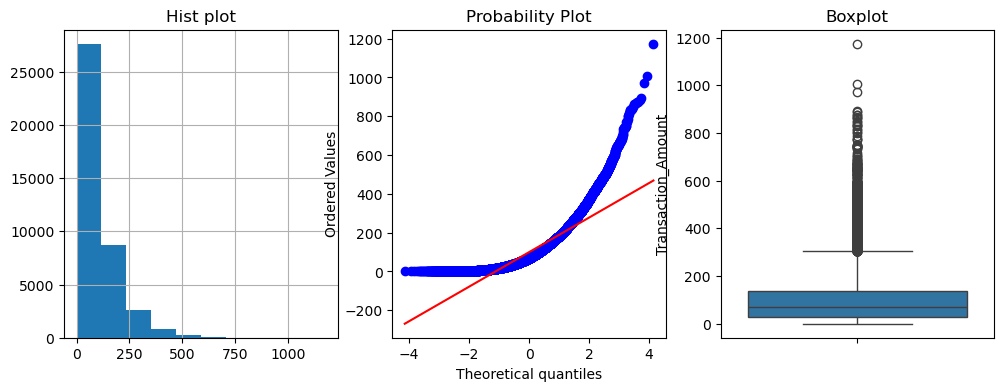

column : Account_Balance


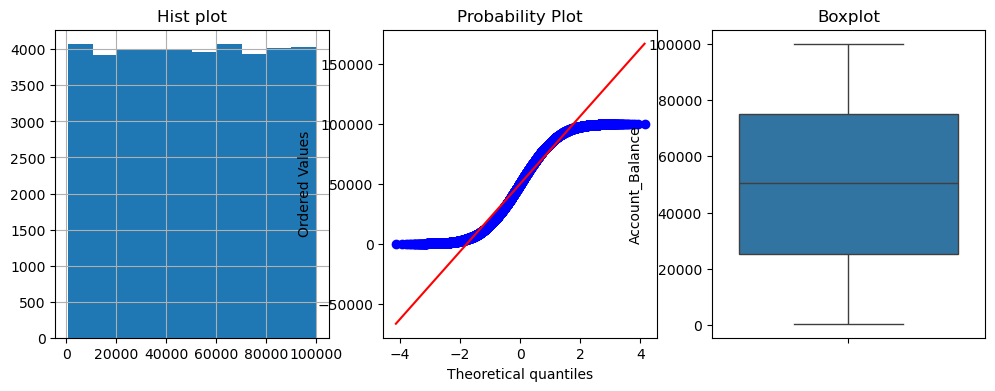

column : IP_Address_Flag


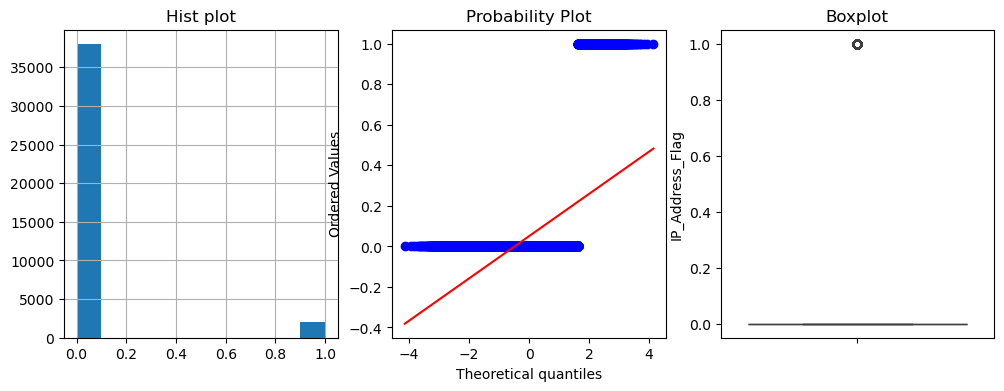

column : Previous_Fraudulent_Activity


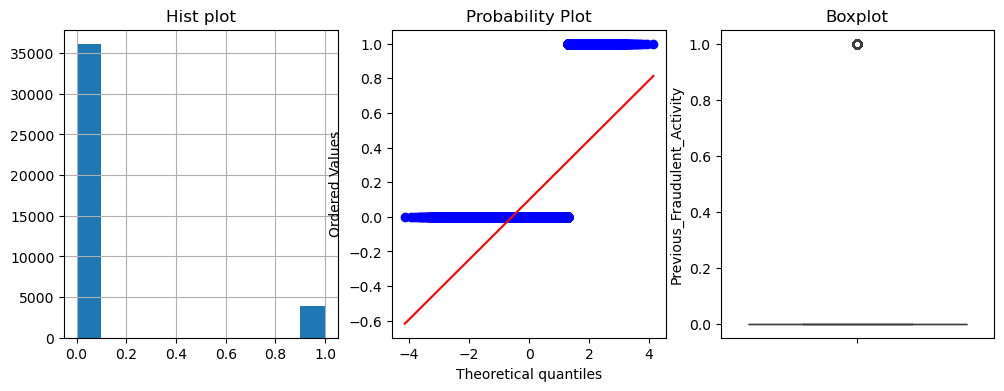

column : Daily_Transaction_Count


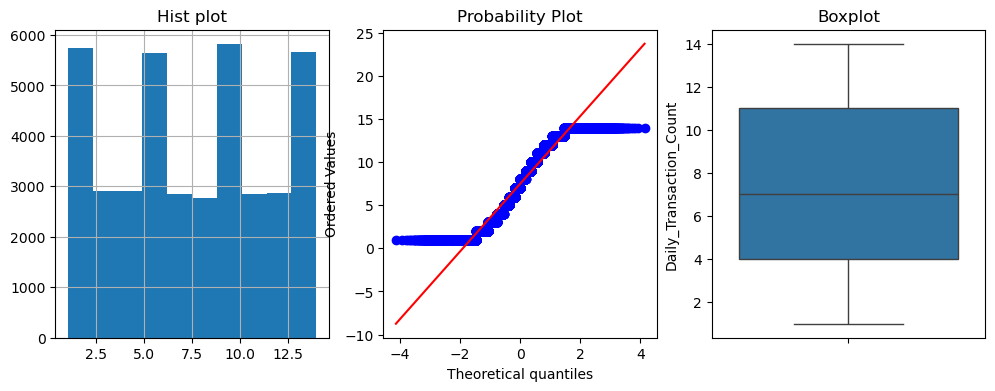

column : Avg_Transaction_Amount_7d


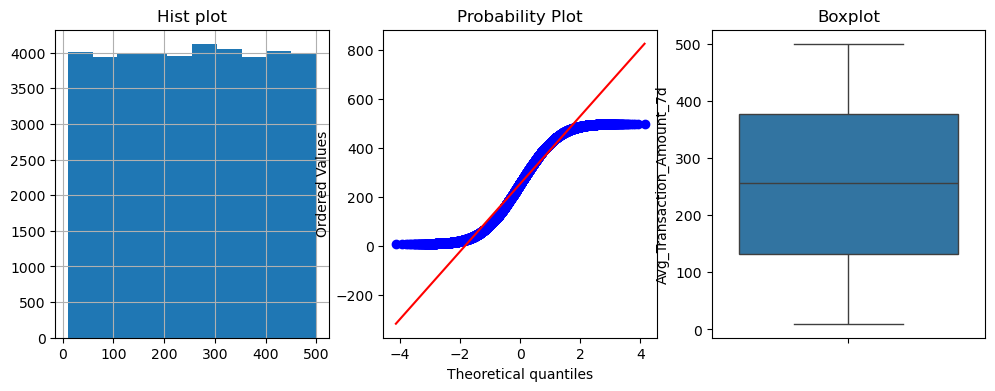

column : Failed_Transaction_Count_7d


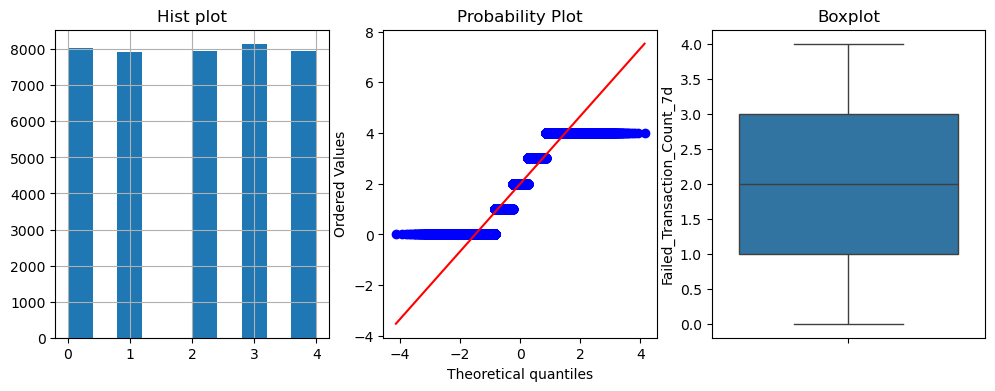

column : Card_Age


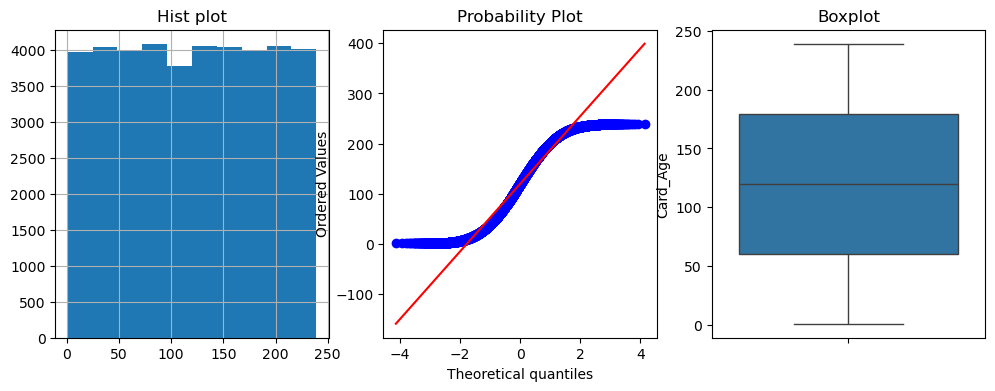

column : Transaction_Distance


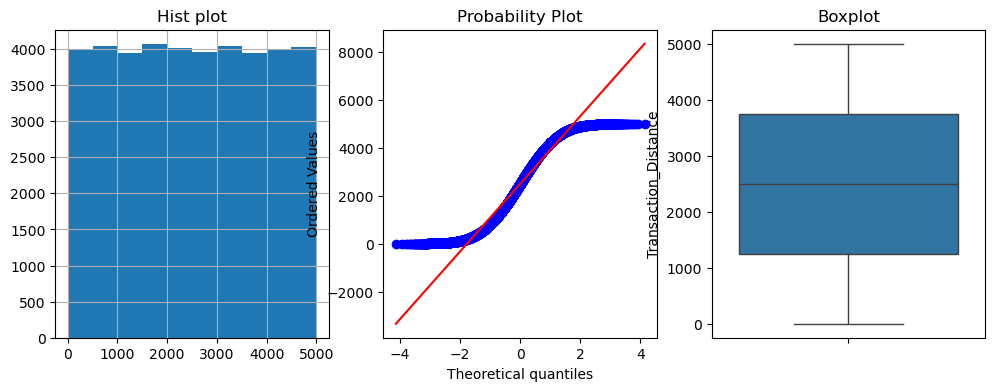

column : Risk_Score


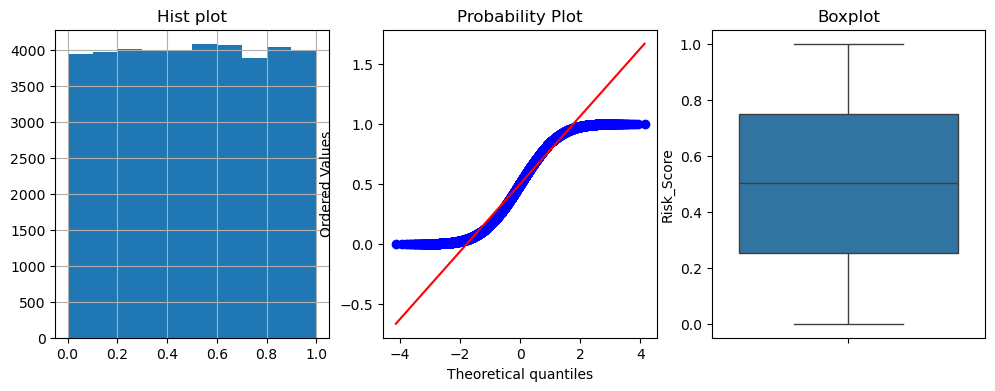

column : Is_Weekend


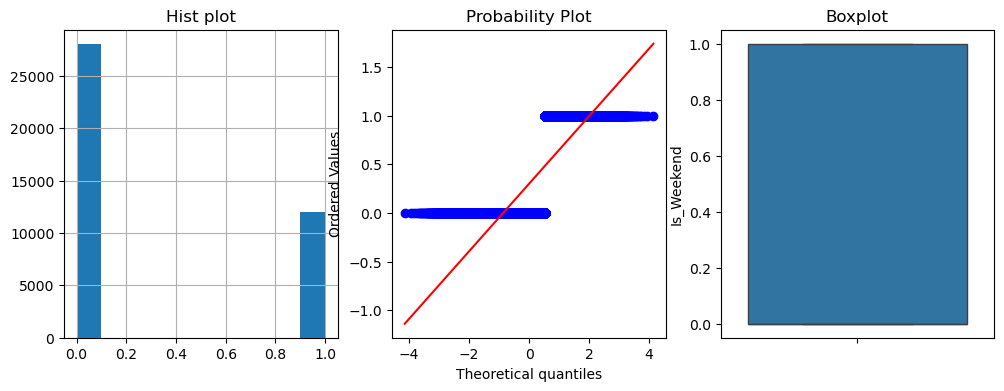

column : Fraud_Label


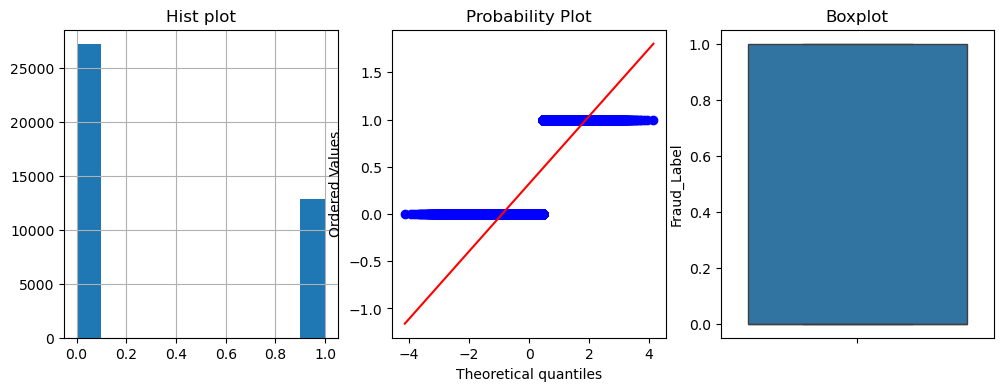

column : Timestamp_month


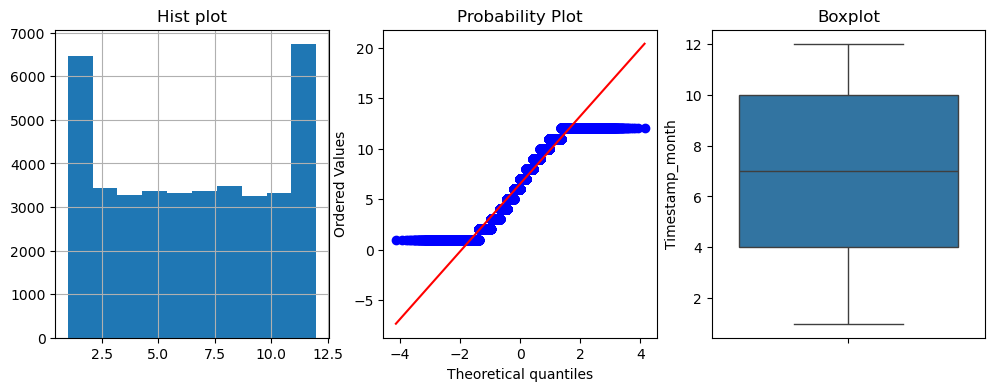

column : Timestamp_day


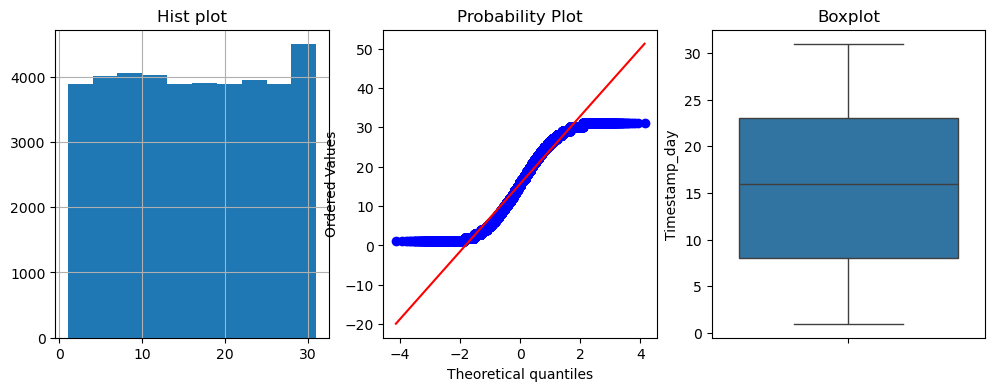

column : Timestamp_hour


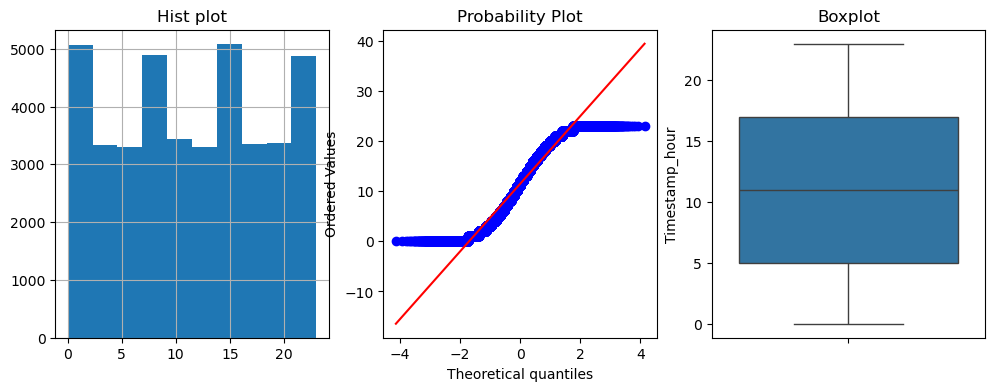

In [54]:
### plotting the graphs for the continuous columns
plot_graphs(num_cols_train, num_cols_train.columns)

In [55]:
### now the numerical_train is ready for the tree based models
num_cols_train.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour
0,80.39,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,4,13,16
1,196.60,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,3,27,5
2,21.88,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,9,27,23
3,121.23,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,9,10,13
4,34.53,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,1,13,6


In [22]:
### setting up the path to save the data (ready for the tree based models)
num_train_processed_path = '../data/intermidiate/num_train_processed.csv'

In [23]:
### saving the data
save_data(num_cols_train, num_train_processed_path)

In [24]:
### veryfying if everything is good
num_train_processed = load_data(num_train_processed_path)
num_train_processed.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour
0,80.39,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,4,13,16
1,196.60,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,3,27,5
2,21.88,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,9,27,23
3,121.23,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,9,10,13
4,34.53,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,1,13,6


##### ***************** valid data *****************

In [25]:
### setting up the data path
num_cols_valid_path = '../data/split_features/num_cols_valid.csv'

In [26]:
### loading the data
num_cols_valid = load_data(num_cols_valid_path)
num_cols_valid.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp
0,19.98,1804.81,0,0,2,350.41,3,214,4568.48,0.6865,1,2023-02-10 02:49:00
1,45.32,46648.03,0,1,11,47.14,1,78,297.39,0.5322,1,2023-03-26 22:32:00
2,32.25,80244.56,0,0,7,160.14,2,59,4792.40,0.4924,0,2023-08-05 12:29:00
3,35.41,24611.99,0,0,3,340.38,4,143,3318.08,0.5503,0,2023-01-22 19:26:00
4,57.80,27154.09,1,0,1,149.80,0,227,573.20,0.2208,0,2023-08-20 12:11:00


In [27]:
### checking the shape
get_shape(num_cols_valid)

(10000, 12)

In [28]:
### checking the nan
get_nan(num_cols_valid)

Transaction_Amount              0
Account_Balance                 0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Age                        0
Transaction_Distance            0
Risk_Score                      0
Is_Weekend                      0
Timestamp                       0
dtype: int64

In [29]:
### checking the info
get_info(num_cols_valid)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_Amount            10000 non-null  float64
 1   Account_Balance               10000 non-null  float64
 2   IP_Address_Flag               10000 non-null  int64  
 3   Previous_Fraudulent_Activity  10000 non-null  int64  
 4   Daily_Transaction_Count       10000 non-null  int64  
 5   Avg_Transaction_Amount_7d     10000 non-null  float64
 6   Failed_Transaction_Count_7d   10000 non-null  int64  
 7   Card_Age                      10000 non-null  int64  
 8   Transaction_Distance          10000 non-null  float64
 9   Risk_Score                    10000 non-null  float64
 10  Is_Weekend                    10000 non-null  int64  
 11  Timestamp                     10000 non-null  object 
dtypes: float64(5), int64(6), object(1)
memory usage: 937.6+ KB


##### col : 'Timestamp'

In [30]:
### using the same pattern setup and checking the patterns
get_format(num_cols_valid, 'Timestamp', patterns = patterns_timestamp)

Timestamp
19    10000
Name: count, dtype: int64
YYYY-MM-DD HH:MM:SS : 10000
YYYY-MM-DD HH:MM : 0
YYYY-MM-DD : 0
YYYY/MM/DD : 0


In [31]:
### starting the split
num_cols_valid = split_col(num_cols_valid, 'Timestamp')
num_cols_valid.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp,Timestamp_year,Timestamp_month,Timestamp_day,Timestamp_hour
0,19.98,1804.81,0,0,2,350.41,3,214,4568.48,0.6865,1,2023-02-10 02:49:00,2023,2,10,2
1,45.32,46648.03,0,1,11,47.14,1,78,297.39,0.5322,1,2023-03-26 22:32:00,2023,3,26,22
2,32.25,80244.56,0,0,7,160.14,2,59,4792.40,0.4924,0,2023-08-05 12:29:00,2023,8,5,12
3,35.41,24611.99,0,0,3,340.38,4,143,3318.08,0.5503,0,2023-01-22 19:26:00,2023,1,22,19
4,57.80,27154.09,1,0,1,149.80,0,227,573.20,0.2208,0,2023-08-20 12:11:00,2023,8,20,12


In [32]:
### checking the value_count in 'Timestamp_year'
get_value_counts(num_cols_valid, 'Timestamp_year')

Timestamp_year
2023    10000
Name: count, dtype: int64

In [33]:
### dropping off the 'Timestamp' and 'Timestamp_year' columns
drop_col(num_cols_valid, ['Timestamp', 'Timestamp_year'])
num_cols_valid.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour
0,19.98,1804.81,0,0,2,350.41,3,214,4568.48,0.6865,1,2,10,2
1,45.32,46648.03,0,1,11,47.14,1,78,297.39,0.5322,1,3,26,22
2,32.25,80244.56,0,0,7,160.14,2,59,4792.40,0.4924,0,8,5,12
3,35.41,24611.99,0,0,3,340.38,4,143,3318.08,0.5503,0,1,22,19
4,57.80,27154.09,1,0,1,149.80,0,227,573.20,0.2208,0,8,20,12


##### dealing with the all columns now

column : Transaction_Amount


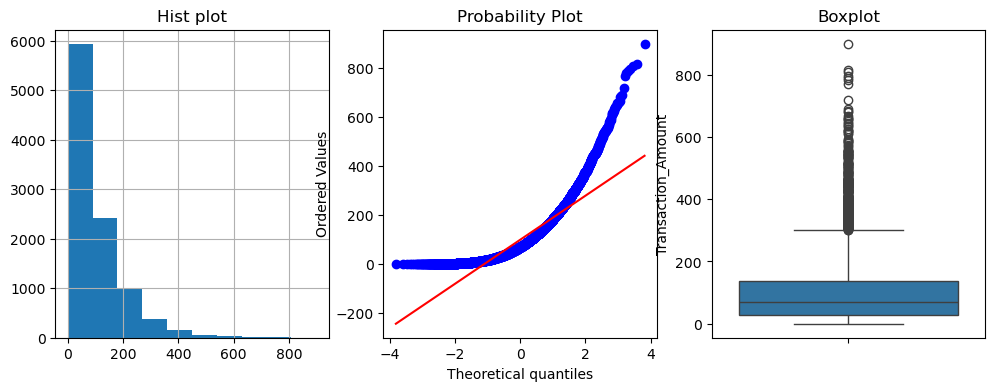

column : Account_Balance


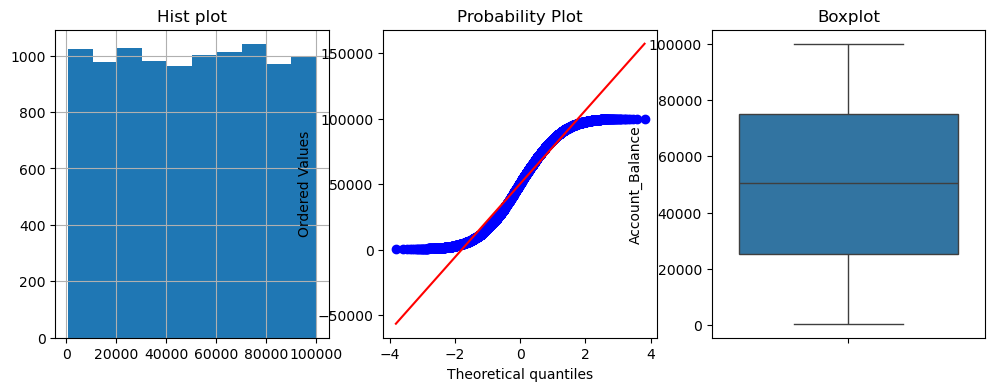

column : IP_Address_Flag


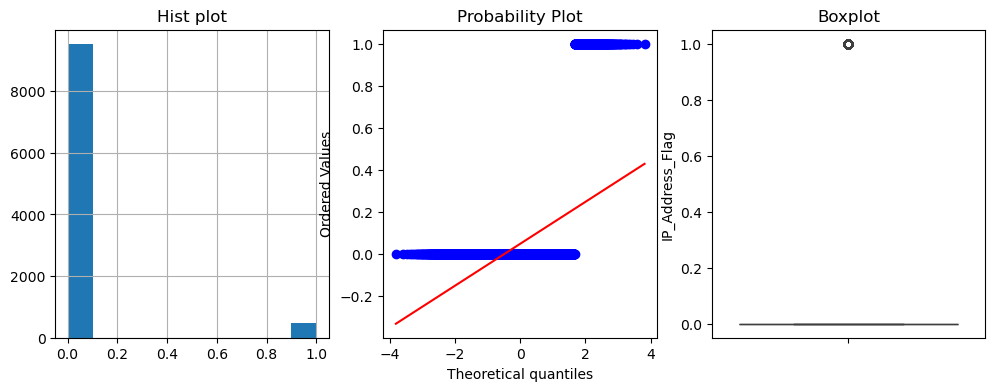

column : Previous_Fraudulent_Activity


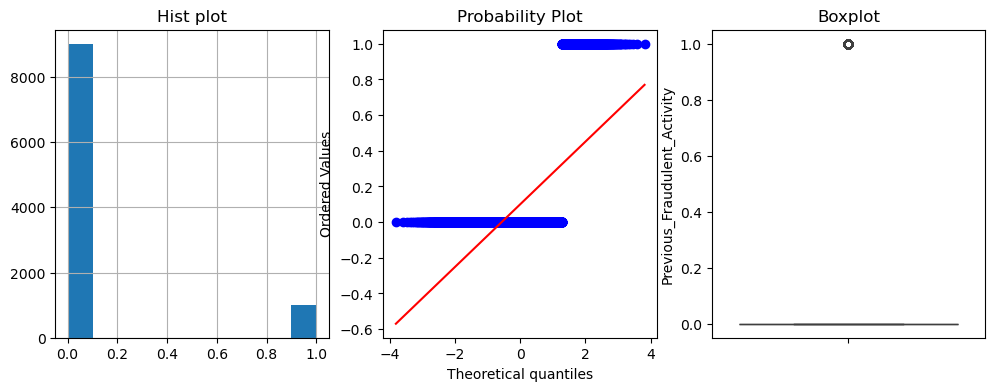

column : Daily_Transaction_Count


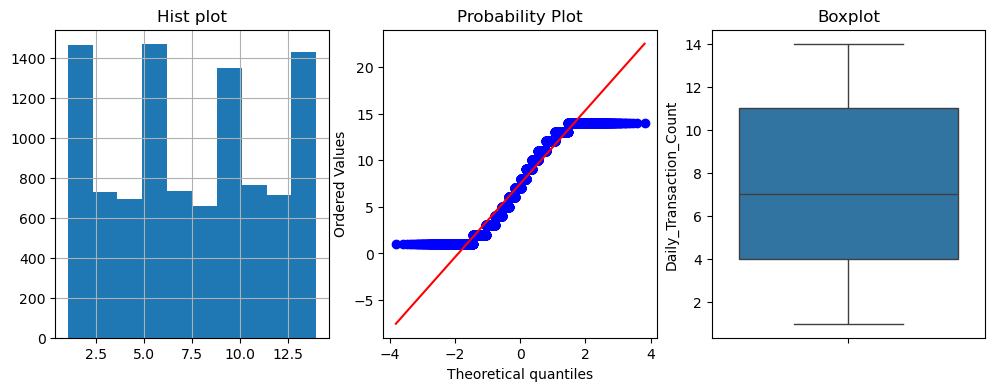

column : Avg_Transaction_Amount_7d


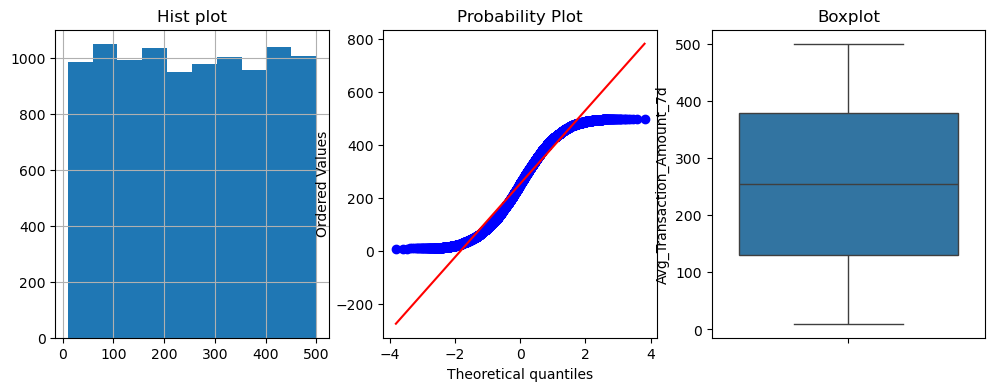

column : Failed_Transaction_Count_7d


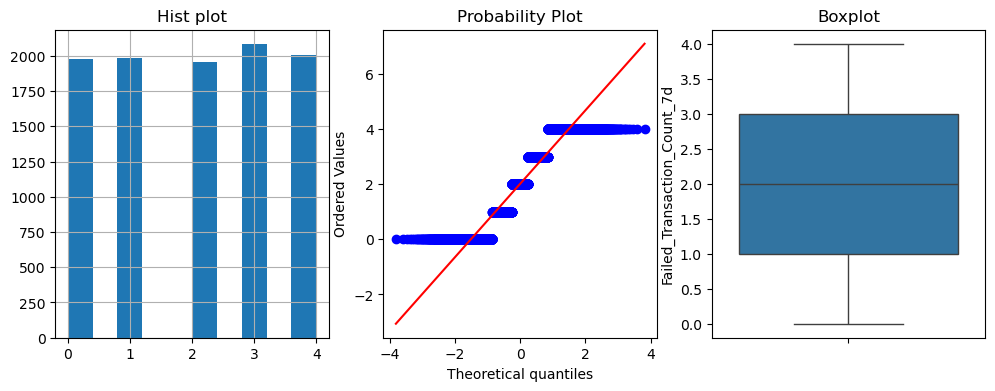

column : Card_Age


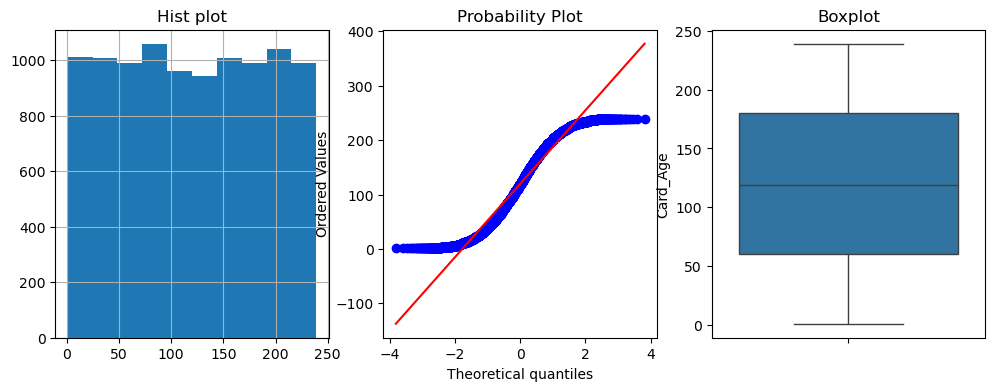

column : Transaction_Distance


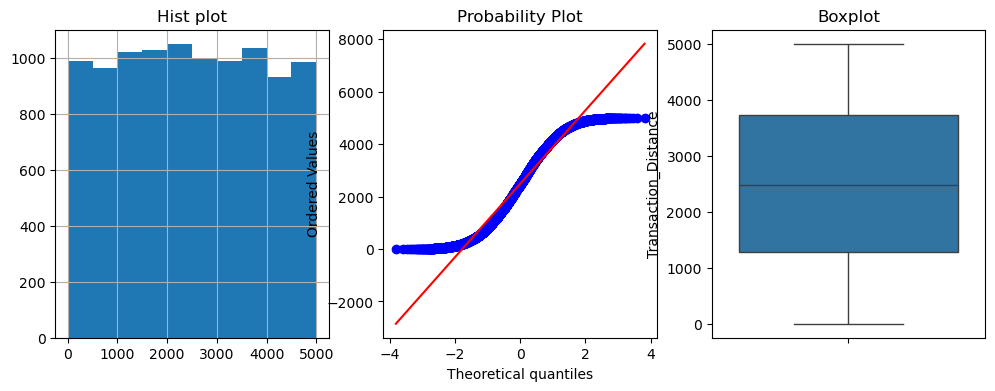

column : Risk_Score


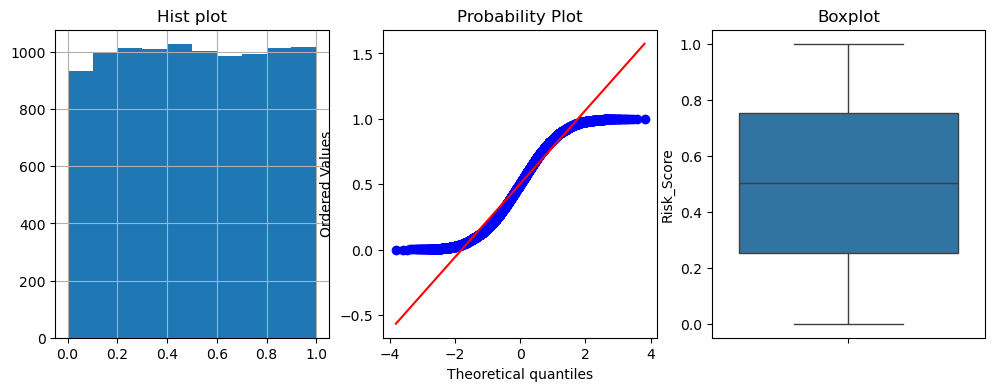

column : Is_Weekend


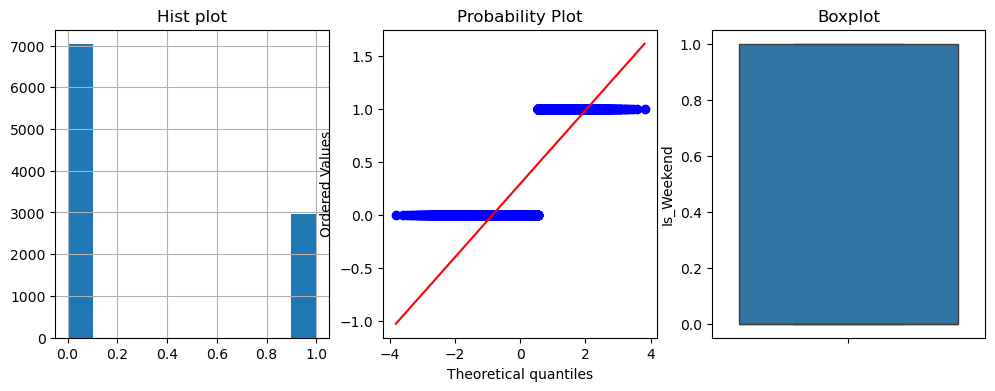

column : Timestamp_month


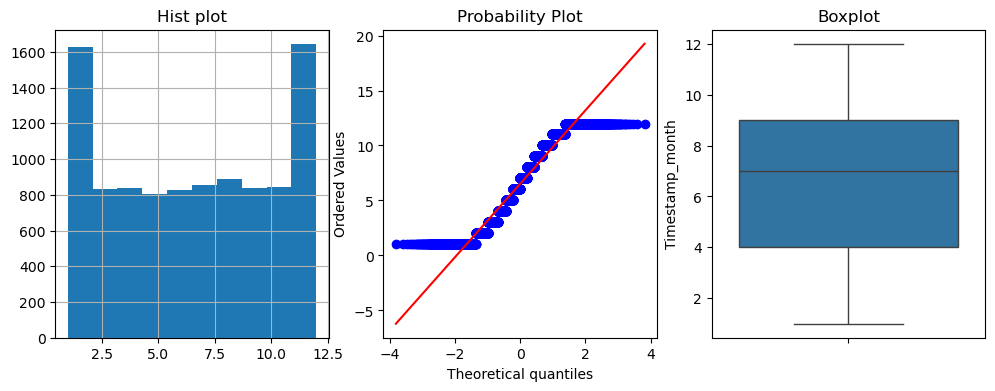

column : Timestamp_day


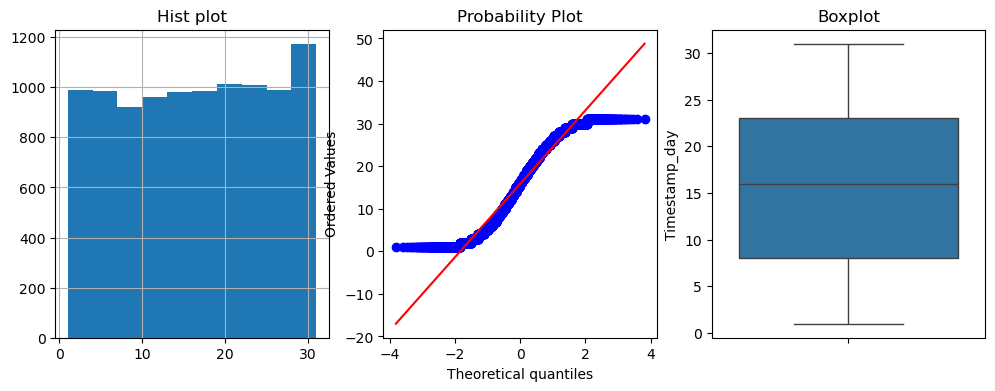

column : Timestamp_hour


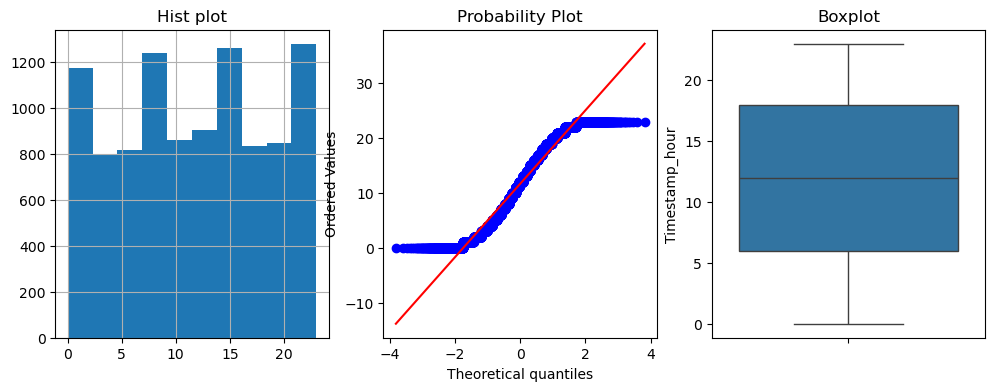

In [56]:
### plotting the graphs for the features
plot_graphs(num_cols_valid, num_cols_valid.columns)

In [57]:
### setting up the data path and saving the data now
num_valid_processed_path = '../data/intermidiate/num_valid_processed.csv'

In [58]:
### saving the data
save_data(num_cols_valid, num_valid_processed_path)

In [59]:
### checking if everything was good
num_valid_processed = load_data(num_train_processed_path)
num_train_processed.head()

,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour
0,80.39,32068.28,0,0,5,112.75,4,142,3674.33,0.3668,0,1,4,13,16
1,196.60,94961.81,0,0,8,199.95,1,32,796.99,0.4866,0,0,3,27,5
2,21.88,39354.55,0,0,7,234.75,2,203,2286.33,0.2961,1,0,9,27,23
3,121.23,46138.99,0,0,8,344.98,2,137,4924.98,0.3362,0,0,9,10,13
4,34.53,52750.58,0,0,6,456.77,1,8,4924.36,0.0804,0,0,1,13,6
